# *Data Cleaning*

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [24]:
df = pd.read_csv(r'CC DIRTY.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (12240, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C30077,1138.82,0.87,6974.45,679.13,2760.79,111.80,0.89,0.18,0.73,0.06,1,21,4303.00,2340.57,435.05,0.07,12
1,C29345,2356.82,0.98,8051.39,5596.14,3478.67,0.00,0.91,0.56,0.56,0.07,1,43,7900.00,2332.23,273.08,0.97,12
2,C23726,2944.24,0.97,7420.29,6770.43,1467.75,318.21,0.93,0.67,0.63,0.00,0,28,11044.00,6982.66,786.22,0.40,12
3,C28521,25.62,0.47,354.43,0.00,62.80,85.57,0.05,0.20,0.04,0.01,0,1,2386.00,371.60,325.19,0.06,12
4,C30497,238.61,0.01,248.83,129.86,56.36,0.00,0.05,0.02,0.01,0.05,1,1,1930.00,348.40,205.10,0.17,12


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           12240 non-null  object 
 1   BALANCE                           11878 non-null  float64
 2   BALANCE_FREQUENCY                 12240 non-null  float64
 3   PURCHASES                         11874 non-null  float64
 4   ONEOFF_PURCHASES                  12240 non-null  float64
 5   INSTALLMENTS_PURCHASES            12240 non-null  float64
 6   CASH_ADVANCE                      11996 non-null  float64
 7   PURCHASES_FREQUENCY               12240 non-null  float64
 8   ONEOFF_PURCHASES_FREQUENCY        12240 non-null  float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  12240 non-null  float64
 10  CASH_ADVANCE_FREQUENCY            12240 non-null  float64
 11  CASH_ADVANCE_TRX                  12240 non-null  int64  
 12  PURC

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,11878.00,2207.43,4180.63,0.00,194.31,1146.27,3288.02,59718.82
BALANCE_FREQUENCY,12240.00,0.66,0.32,0.00,0.35,0.82,0.95,1.00
PURCHASES,11874.00,3166.45,5945.99,0.00,200.52,465.44,4939.07,79580.36
ONEOFF_PURCHASES,12240.00,1230.56,2317.14,0.00,104.78,243.17,524.23,10935.66
INSTALLMENTS_PURCHASES,12240.00,1583.37,1894.00,0.00,67.90,203.90,3357.66,7305.41
CASH_ADVANCE,11996.00,1335.51,3653.58,0.00,8.79,108.98,324.96,49976.18
PURCHASES_FREQUENCY,12240.00,0.46,0.36,0.00,0.15,0.26,0.88,1.05
ONEOFF_PURCHASES_FREQUENCY,12240.00,0.21,0.25,0.00,0.06,0.12,0.20,1.02
PURCHASES_INSTALLMENTS_FREQUENCY,12240.00,0.35,0.34,0.00,0.07,0.14,0.71,1.05
CASH_ADVANCE_FREQUENCY,12240.00,0.16,0.26,0.00,0.02,0.04,0.08,0.91


# *Handle Missing & Duplicated Values*

In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
                  Missing Count  Missing %
BALANCE                     362       2.96
PURCHASES                   366       2.99
CASH_ADVANCE                244       1.99
CREDIT_LIMIT                496       4.05
MINIMUM_PAYMENTS            860       7.03
Duplicate rows: 229


In [28]:
# Removing duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(f"Rows before : {before}")
print(f"Rows removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 12240
Rows removed: 229
Rows after  : 12011


In [29]:
df = df.fillna(df.median(numeric_only=True))

In [30]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

# *Check and handle outliers*

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
def detect_outliers_iqr(df, col, multiplier=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers.index, lower, upper

print(f"{'Column':<35} {'Outliers':>10} {'Lower':>12} {'Upper':>12}")
print("-" * 72)

outlier_summary = {}
for col in numeric_cols:
    idx, low, up = detect_outliers_iqr(df, col)
    if len(idx) > 0:
        outlier_summary[col] = idx
        print(f"{col:<35} {len(idx):>10,} {low:>12.2f} {up:>12.2f}")

print(f"\nTotal outlier rows detected: {len(set([i for idx in outlier_summary.values() for i in idx])):,}")

Column                                Outliers        Lower        Upper
------------------------------------------------------------------------
BALANCE                                     80     -8782.19     12179.35
PURCHASES                                   80    -13754.46     18818.17
ONEOFF_PURCHASES                         2,058     -1153.11      1783.44
CASH_ADVANCE                             2,645      -892.23      1214.12
ONEOFF_PURCHASES_FREQUENCY               1,720        -0.35         0.61
CASH_ADVANCE_FREQUENCY                   2,568        -0.18         0.28
CASH_ADVANCE_TRX                         1,571        -6.00         8.00
CREDIT_LIMIT                                12    -10952.50     19690.00
PAYMENTS                                   200     -7354.09     10512.80
MINIMUM_PAYMENTS                           449      -912.51      1719.53
PRC_FULL_PAYMENT                         1,637        -0.34         0.50
TENURE                                   1,785     

In [32]:
df_clean = df.copy()
for col, idx in outlier_summary.items():
    _, low, up = detect_outliers_iqr(df, col)
    df_clean[col] = df_clean[col].clip(lower=low, upper=up)
    print(f"{col:<35} → clipped to [{low:.2f}, {up:.2f}]")

print(f"\nDone! Shape: {df_clean.shape}")

BALANCE                             → clipped to [-8782.19, 12179.35]
PURCHASES                           → clipped to [-13754.46, 18818.17]
ONEOFF_PURCHASES                    → clipped to [-1153.11, 1783.44]
CASH_ADVANCE                        → clipped to [-892.23, 1214.12]
ONEOFF_PURCHASES_FREQUENCY          → clipped to [-0.35, 0.61]
CASH_ADVANCE_FREQUENCY              → clipped to [-0.18, 0.28]
CASH_ADVANCE_TRX                    → clipped to [-6.00, 8.00]
CREDIT_LIMIT                        → clipped to [-10952.50, 19690.00]
PAYMENTS                            → clipped to [-7354.09, 10512.80]
MINIMUM_PAYMENTS                    → clipped to [-912.51, 1719.53]
PRC_FULL_PAYMENT                    → clipped to [-0.34, 0.50]
TENURE                              → clipped to [12.00, 12.00]

Done! Shape: (12011, 18)


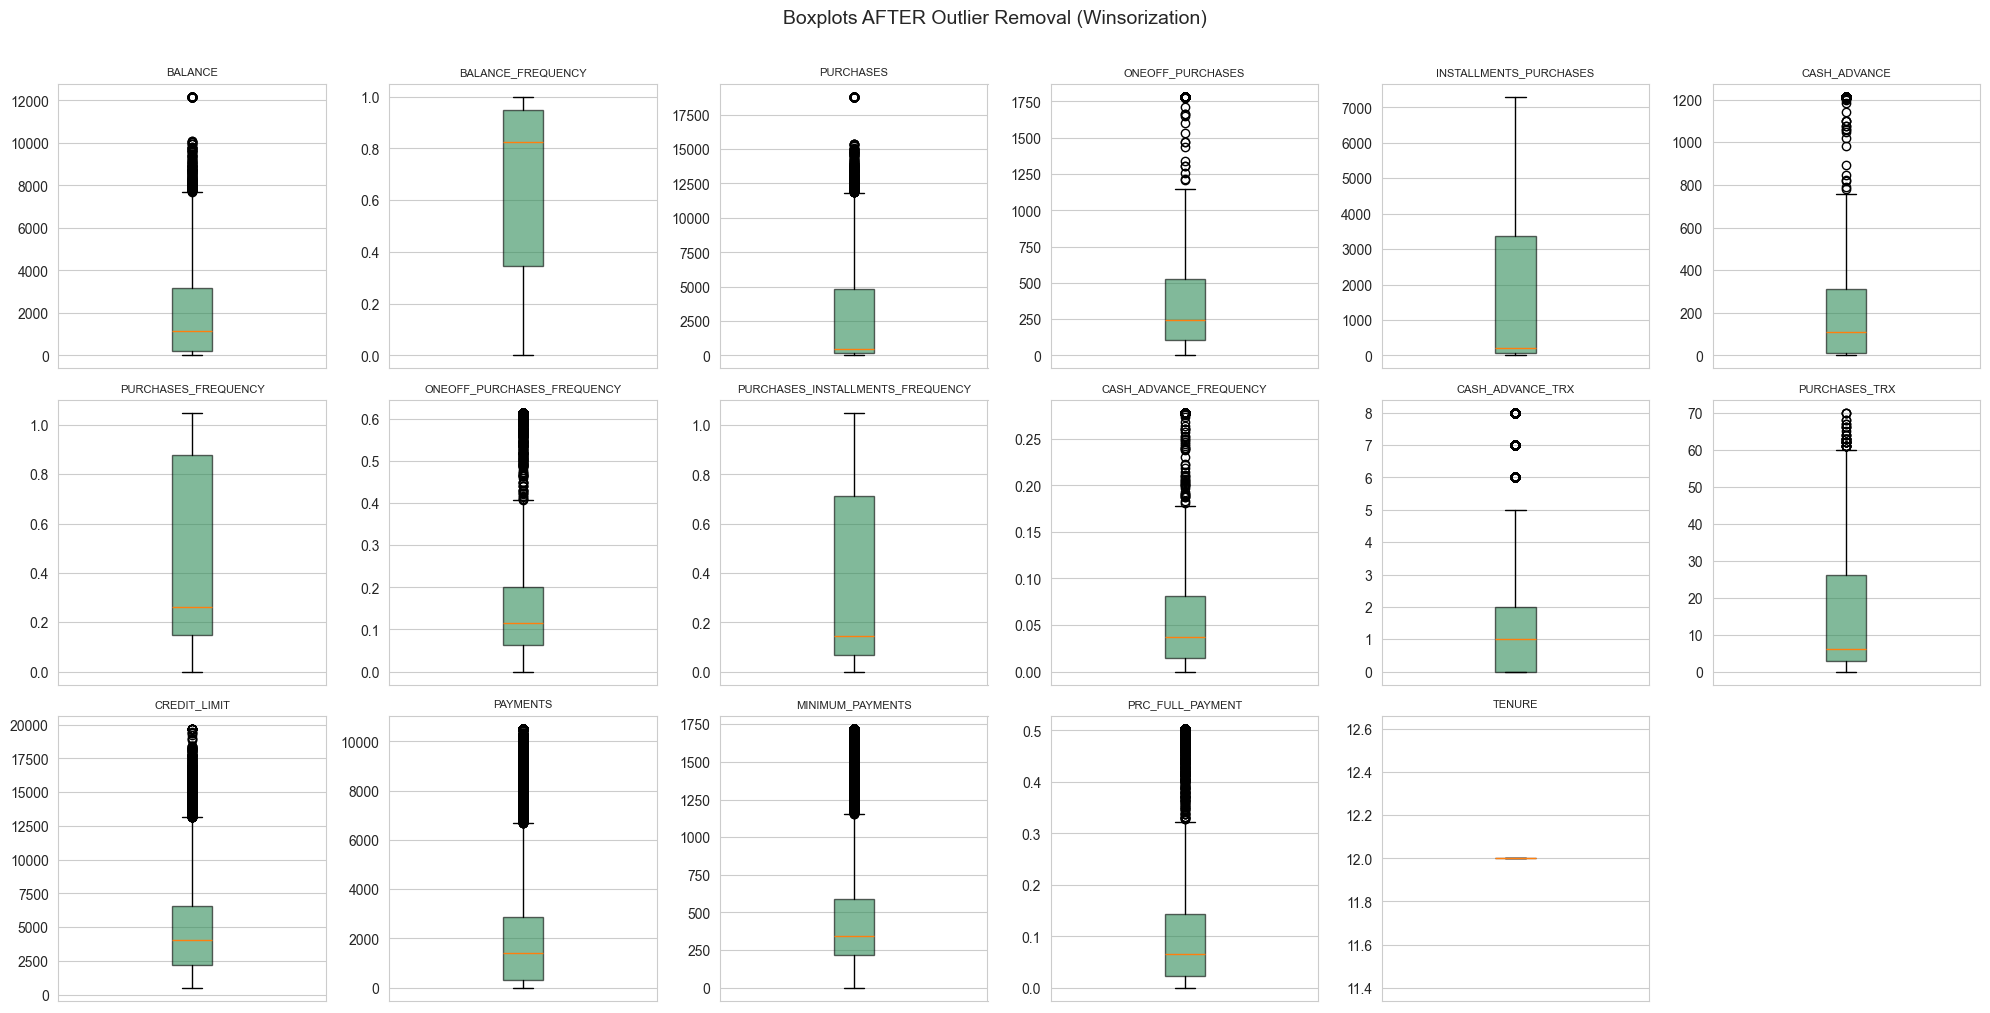

In [33]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots AFTER Outlier Removal (Winsorization)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# *Scalling*

In [34]:
features = df_clean.drop(columns=['CUST_ID'])

scaler = StandardScaler()
scaled_array = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_array, columns=features.columns)

print("Scaling done using StandardScaler")
print(f"   Mean ≈ 0 and Std ≈ 1 for all features")
print(f"\nSample stats after scaling:")
df_scaled[features.columns[:5]].describe().loc[['mean','std']].round(3)

Scaling done using StandardScaler
   Mean ≈ 0 and Std ≈ 1 for all features

Sample stats after scaling:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
mean,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00


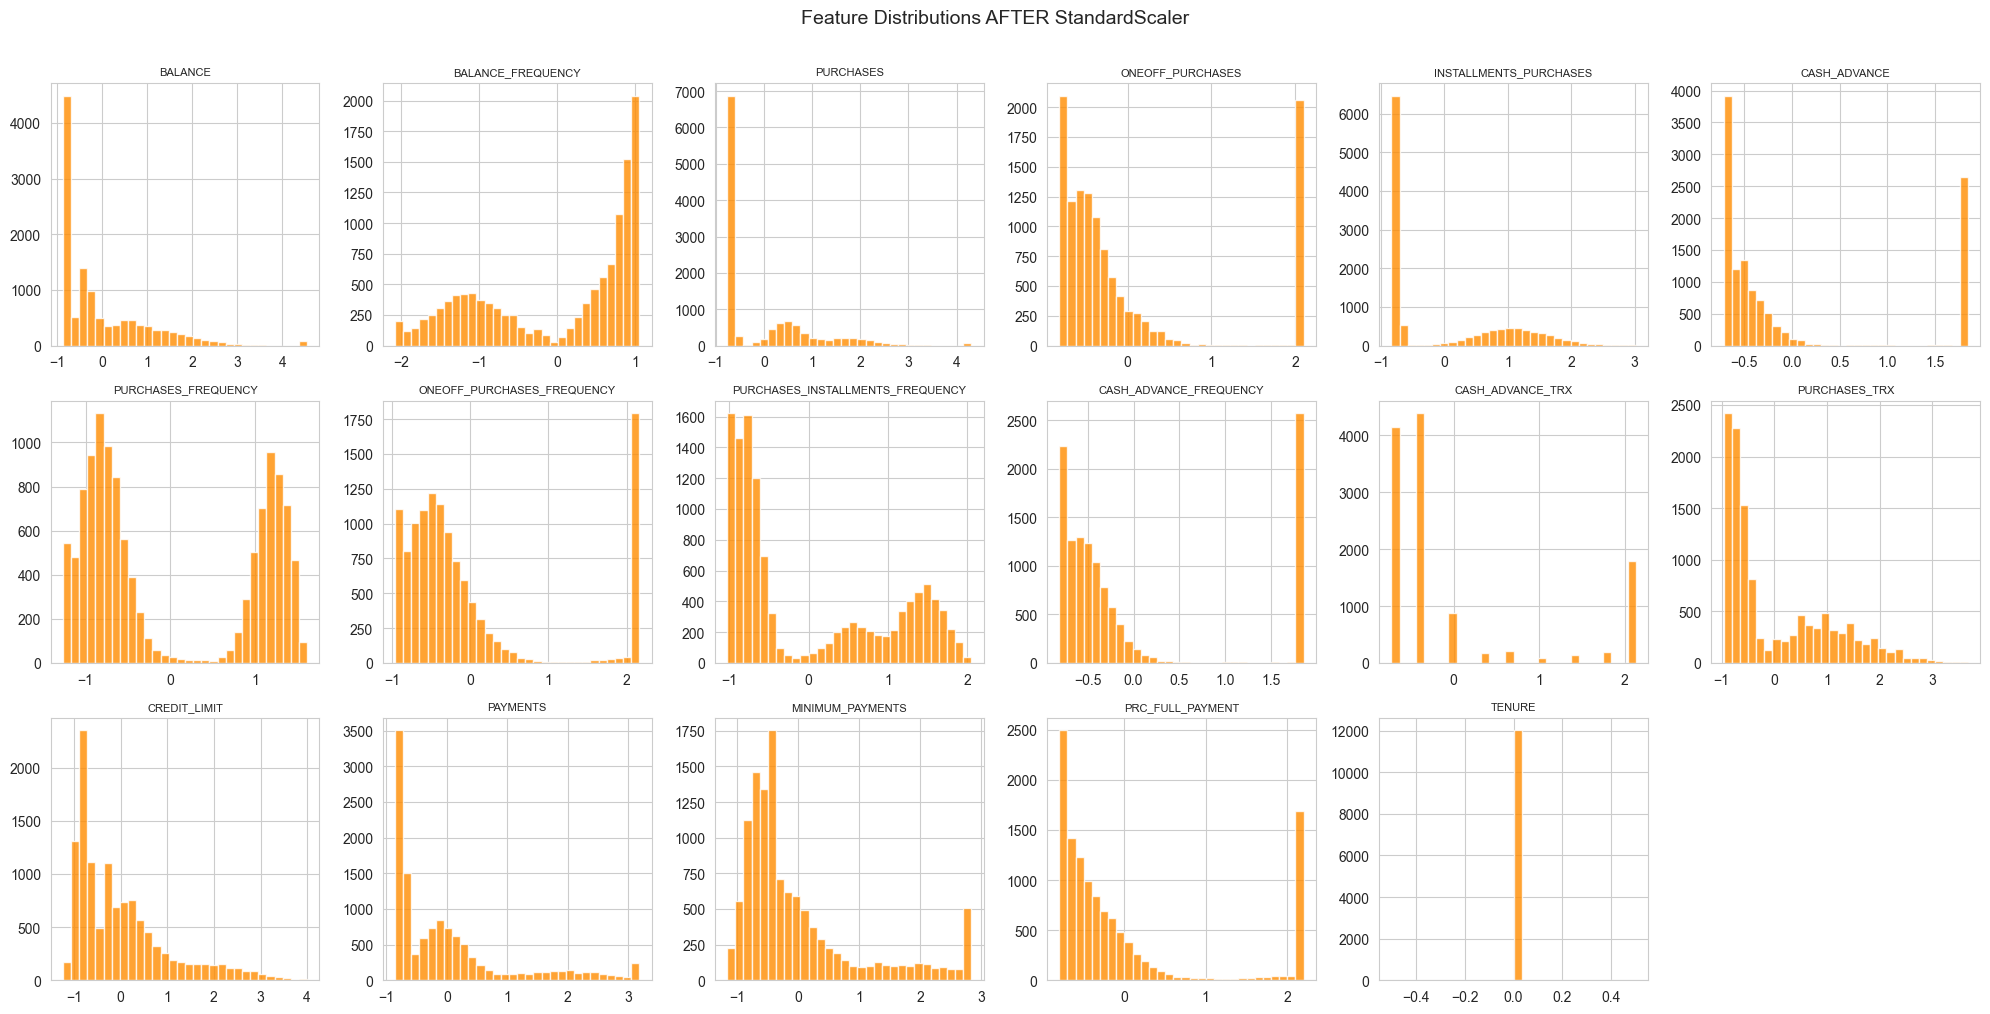

In [35]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(features.columns):
    axes[i].hist(df_scaled[col], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions AFTER StandardScaler', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# *PCA Plotting*

In [36]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_array)

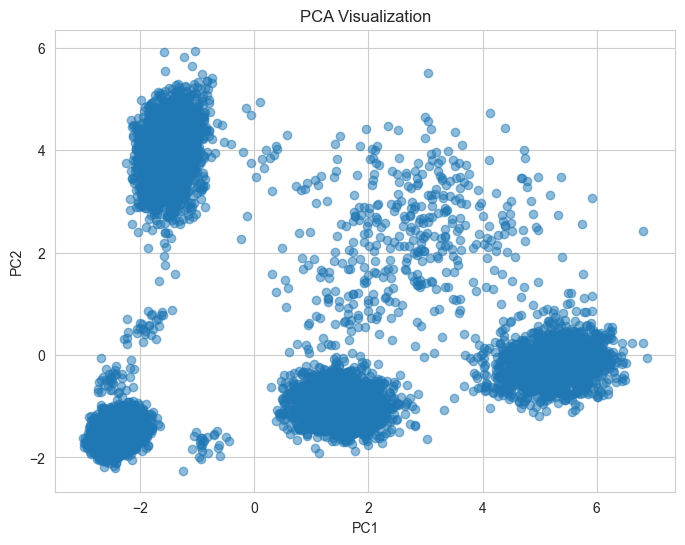

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.title('PCA Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()